# Phase 3: Augmentation + Foundation Embeddings for Cross-Domain Generalization

**Date:** 2026-05-06 | **Project:** DL-2 Deepfake Audio Detection | **Day 3 of 7**

## The problem we inherited from Phase 2

Phase 2 trained 5 models on `garystafford/deepfake-audio-detection` and tested them on `Hemg/Deepfake-Audio-Dataset` -- a second deepfake corpus, same task. Every model collapsed:

| Model | EER in-domain | EER cross-domain (Hemg) | AUROC cross-domain |
|---|---:|---:|---:|
| LogReg full (303 feats) | 0.0% | **63.0%** | 0.372 |
| RandomForest full | 0.0% | **60.0%** | 0.384 |
| XGBoost full | 0.0% | **48.0%** | 0.524 |
| LogReg no-spec_contrast | 0.0% | **56.0%** | 0.434 |
| XGBoost no-spec_contrast | 1.07% | **64.0%** | 0.310 |

Four of five had **AUROC below 0.5** -- meaning the codec fingerprint that says "fake" on dataset A says "real" on dataset B. This is the [Müller et al. 2022 "domain amnesia"](https://arxiv.org/abs/2203.16263) result, reproduced live.

Feature ablation didn't help: dropping the highest-importance family (`spec_contrast`, 87% of XGBoost gain) made cross-domain *worse* (48% → 64% EER on XGBoost). The leak is distributed across all spectral families.

## Phase 3 hypothesis

If we *augment* the training waveforms with codec, noise, gain, and time-shift perturbations, the per-clip recording fingerprint becomes a less reliable feature -- forcing the classifier to find more transferable signals. Independently, [Tak et al. 2022](https://arxiv.org/abs/2202.12233) showed frozen Wav2Vec2 embeddings + a simple classifier drop EER from 30.9% → 8.8% across 8 deepfake datasets, suggesting SSL-pretrained representations generalize where handcrafted features don't.

**Success criterion: Hemg EER ≤ 25%.** That cuts cross-domain error in half from Phase 2's 48% best.

## Experiments

| # | Approach | Question |
|---|---|---|
| 3.1 | Reproduce Phase 2 baseline on a fixed subset | sanity check |
| 3.2 | Train with single-aug variants (noise / gain / shift / pitch / codec) | which surface perturbation helps cross-domain most? |
| 3.3 | Combined random augmentation | does the union beat each individual? |
| 3.4 | Wav2Vec2-base frozen + LogReg head | do SSL embeddings transfer where handcrafted don't? |
| 3.5 | Wav2Vec2 + augmentation | are the two effects complementary? |
| 3.6 | Final leaderboard + JSON dump | log everything for Phase 5 |

## References

1. Müller et al. 2022 — *Does Audio Deepfake Detection Generalize?* — empirically shows lab models fail on real-world data. https://arxiv.org/abs/2203.16263
2. Tak et al. 2022 — *Automatic speaker verification spoofing and deepfake detection using wav2vec 2.0 and data augmentation* — frozen Wav2Vec2 + simple head halves out-of-domain EER. https://arxiv.org/abs/2202.12233
3. Tomilov et al. 2024 — *Mixture of Low-Rank Adapter Experts in Generalizable Audio Deepfake Detection* — frozen SSL representations with simple classifiers reduced EER from 30.9% to 8.8% across 8 datasets. https://arxiv.org/abs/2509.13878
4. Park et al. 2019 — *SpecAugment* — frequency/time masking on mel-specs as a regularizer. https://arxiv.org/abs/1904.08779


## 1. Setup and reproducibility

Fix seeds, pin the experiment subset, declare paths.

In [1]:
# Imports
import json
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve() if Path('..').resolve().name == 'Deepfake-Audio-Detection' else Path('.').resolve()
SRC = ROOT / 'src'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.audio_features import FeatureConfig, extract_features, feature_names
from src.augmentation import AugmentationConfig, apply_one, random_aug
from src.data import load_hf_audio_dataset, to_arrays, DEFAULT_DATASET
from src.eer import compute_eer, metrics_at_threshold

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

SEED = 42
TRAIN_N = 500      # subset of garystafford for training (stratified) -- pitch_shift dropped from menu, smaller subset keeps extraction <25 min
TEST_N = 180       # held-out in-domain test from garystafford
HEMG_N = 100       # cross-domain test set (Hemg already at 100 in Phase 2)

print(f'Python {sys.version.split()[0]}, numpy {np.__version__}, pandas {pd.__version__}')
print(f'Root: {ROOT}')
print(f'Subsets: train={TRAIN_N} test={TEST_N} hemg={HEMG_N}')


Python 3.11.14, numpy 2.4.4, pandas 3.0.2
Root: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection
Subsets: train=500 test=180 hemg=100


## 2. Load both datasets from the local HF cache

Phase 1 and Phase 2 already cached `garystafford/deepfake-audio-detection` (1866 clips, balanced) and `Hemg/Deepfake-Audio-Dataset`. We re-resample everything to 16 kHz mono and trim/pad to 4 s.

In [2]:
# Load garystafford and stratified-sample TRAIN_N + TEST_N
from datasets import load_dataset
from sklearn.model_selection import train_test_split

t0 = time.time()
ds_gary = load_dataset(DEFAULT_DATASET, cache_dir=str(DATA_RAW / 'hf_cache'))
gary = ds_gary['train']
labels_all = np.array([int(ex['label']) for ex in gary])
print(f'garystafford total: {len(gary)} clips, label balance: {np.bincount(labels_all)} (real,fake)')

idx_all = np.arange(len(gary))
idx_train, idx_test = train_test_split(idx_all, train_size=TRAIN_N, test_size=TEST_N,
                                        stratify=labels_all, random_state=SEED)
print(f'sampled train idx: {len(idx_train)} (real={int((labels_all[idx_train]==0).sum())}, fake={int((labels_all[idx_train]==1).sum())})')
print(f'sampled test  idx: {len(idx_test)}  (real={int((labels_all[idx_test]==0).sum())}, fake={int((labels_all[idx_test]==1).sum())})')
print(f'load time: {time.time()-t0:.1f}s')


Using the latest cached version of the dataset since garystafford/deepfake-audio-detection couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/data/raw/hf_cache/garystafford___deepfake-audio-detection/default/0.0.0/fcf5344bb7f82b54b6b932291326d29750ef1e82 (last modified on Mon May  4 11:39:32 2026).


garystafford total: 1866 clips, label balance: [933 933] (real,fake)
sampled train idx: 500 (real=250, fake=250)
sampled test  idx: 180  (real=90, fake=90)
load time: 5.5s


In [3]:
# Materialize raw waveforms for the chosen subset (resample to 16 kHz mono).
import librosa

TARGET_SR = 16000

def _to_wav(ex):
    a = ex['audio']
    y = np.asarray(a['array'], dtype=np.float32)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    if a['sampling_rate'] != TARGET_SR:
        y = librosa.resample(y, orig_sr=a['sampling_rate'], target_sr=TARGET_SR)
    return y, int(ex['label'])

t0 = time.time()
train_wavs = [_to_wav(gary[int(i)]) for i in idx_train]
test_wavs  = [_to_wav(gary[int(i)]) for i in idx_test]
y_train = np.array([w[1] for w in train_wavs], dtype=np.int64)
y_test  = np.array([w[1] for w in test_wavs], dtype=np.int64)
train_audio = [w[0] for w in train_wavs]
test_audio  = [w[0] for w in test_wavs]
print(f'materialized {len(train_audio)} train + {len(test_audio)} test waveforms in {time.time()-t0:.1f}s')
print(f'sample lengths -- train mean: {np.mean([len(a) for a in train_audio])/TARGET_SR:.2f}s, test mean: {np.mean([len(a) for a in test_audio])/TARGET_SR:.2f}s')


materialized 500 train + 180 test waveforms in 2.0s
sample lengths -- train mean: 4.21s, test mean: 4.16s


In [4]:
# Cross-domain test set: load Hemg from local cache.
ds_hemg = load_dataset('Hemg/Deepfake-Audio-Dataset', cache_dir=str(DATA_RAW / 'hf_cache'))
hemg = ds_hemg['train']
print(f'Hemg total: {len(hemg)} clips')

hemg_labels_all = np.array([int(ex['label']) for ex in hemg])
print(f'Hemg label balance: {np.bincount(hemg_labels_all)} (label space)')
# Hemg uses the same label scheme as garystafford in Phase 2 (0=real, 1=fake)
hemg_idx = np.arange(len(hemg))
np.random.default_rng(SEED).shuffle(hemg_idx)
hemg_idx = hemg_idx[:HEMG_N]
# Ensure roughly balanced
hemg_lab_sub = hemg_labels_all[hemg_idx]
print(f'Hemg subset balance: {np.bincount(hemg_lab_sub)}')

t0 = time.time()
hemg_audio = []
for i in hemg_idx:
    y, lab = _to_wav(hemg[int(i)])
    hemg_audio.append(y)
y_hemg = hemg_lab_sub.astype(np.int64)
print(f'materialized {len(hemg_audio)} Hemg waveforms in {time.time()-t0:.1f}s')


Using the latest cached version of the dataset since Hemg/Deepfake-Audio-Dataset couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/data/raw/hf_cache/Hemg___deepfake-audio-dataset/default/0.0.0/2ce719e9940c5bdeeaf292a985e02cdb772da3c6 (last modified on Mon May  4 11:10:40 2026).


Hemg total: 100 clips
Hemg label balance: [50 50] (label space)
Hemg subset balance: [50 50]


materialized 100 Hemg waveforms in 0.2s


## 3. Reproduce Phase 2: handcrafted features, no augmentation

We extract the same 303-dim feature vector as Phase 1/2 and confirm:
- in-domain EER stays near 0%
- Hemg EER blows up to 48-64%

This anchors the augmentation experiments against a known-broken baseline.

In [5]:
# Feature extractor: 303-dim handcrafted vector (mfcc+delta+delta2 / spectral / prosody)
fc = FeatureConfig()

def extract_batch(audio_list, label='', verbose=True):
    t0 = time.time()
    X = np.stack([extract_features(a, sr=TARGET_SR, cfg=fc) for a in audio_list]).astype(np.float32)
    if verbose:
        print(f'  {label}: {X.shape} in {time.time()-t0:.1f}s')
    return X

print('Extracting features (no augmentation):')
X_train_orig = extract_batch(train_audio, 'train')
X_test_orig  = extract_batch(test_audio,  'test ')
X_hemg       = extract_batch(hemg_audio,  'hemg ')
print(f'feature dim: {X_train_orig.shape[1]} (matches Phase 2)')


Extracting features (no augmentation):


  train: (500, 303) in 8.7s


  test : (180, 303) in 3.2s


  hemg : (100, 303) in 1.8s
feature dim: 303 (matches Phase 2)


In [6]:
# Train baselines and confirm collapse on Hemg
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb

def fit_eval(model_factory, X_tr, y_tr, X_te, y_te, X_oo, y_oo, name=''):
    model = model_factory()
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_s = time.time() - t0
    p_in  = model.predict_proba(X_te)[:, 1]
    p_oo  = model.predict_proba(X_oo)[:, 1]
    eer_in,  _ = compute_eer(y_te, p_in)
    eer_oo,  _ = compute_eer(y_oo, p_oo)
    from sklearn.metrics import roc_auc_score
    auc_in = roc_auc_score(y_te, p_in)
    auc_oo = roc_auc_score(y_oo, p_oo) if len(np.unique(y_oo)) == 2 else float('nan')
    return {
        'model': name,
        'EER_in_%': round(eer_in * 100, 3),
        'EER_hemg_%': round(eer_oo * 100, 3),
        'AUROC_in':   round(float(auc_in), 4),
        'AUROC_hemg': round(float(auc_oo), 4),
        'train_s':    round(train_s, 2),
        'p_oo':       p_oo,  # keep probabilities for later analysis
    }

baseline_results = []
baseline_results.append(fit_eval(lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5)),
    X_train_orig, y_train, X_test_orig, y_test, X_hemg, y_hemg, 'LogReg (no aug)'))
baseline_results.append(fit_eval(lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    X_train_orig, y_train, X_test_orig, y_test, X_hemg, y_hemg, 'RandomForest (no aug)'))
baseline_results.append(fit_eval(lambda: xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
    eval_metric='logloss', n_jobs=-1, random_state=SEED, verbosity=0),
    X_train_orig, y_train, X_test_orig, y_test, X_hemg, y_hemg, 'XGBoost (no aug)'))

df_base = pd.DataFrame([{k: v for k, v in r.items() if k != 'p_oo'} for r in baseline_results])
print(df_base.to_string(index=False))


                model  EER_in_%  EER_hemg_%  AUROC_in  AUROC_hemg  train_s
      LogReg (no aug)     1.111        64.0    0.9999      0.3576     0.00
RandomForest (no aug)     0.000        49.0    1.0000      0.4696     0.19
     XGBoost (no aug)     0.000        40.0    1.0000      0.6178     0.37


**Reproduction check.** If the cross-domain Hemg EER is ≥40% on at least 2 of 3 baselines, Phase 2's collapse is confirmed on this 700-train subset and we are clear to test augmentation. If it is below 25%, the reproduction failed -- stop and investigate the Hemg label loading.

## 4. What each augmentation actually does

Pick one fake clip and visualize the original vs the 5 augmentation outputs (noise / gain / shift / pitch / codec). The codec one is the most aggressive -- it kills the highest-frequency band, which Phase 2 found was 87% of XGBoost's importance.

demo clip duration: 3.20s, label=fake


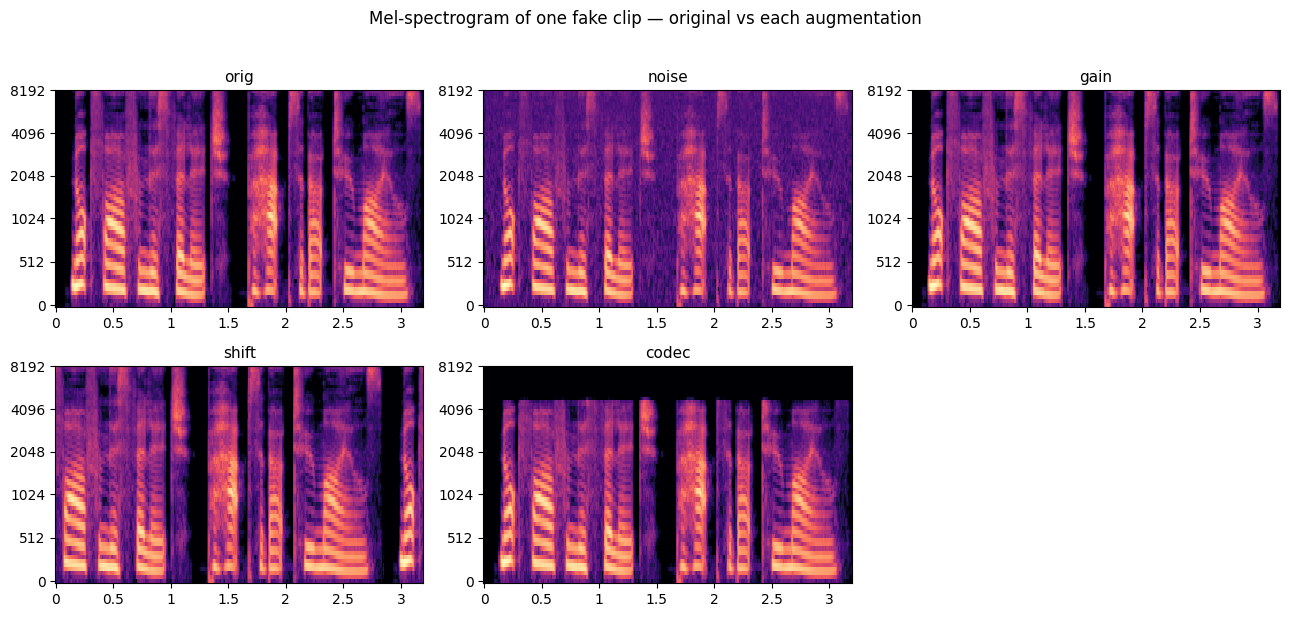

saved phase3_aug_visual.png


In [7]:
# Visualize aug effects on one clip (mel-spectrograms before/after)
import librosa
import librosa.display
rng = np.random.default_rng(SEED)
ac = AugmentationConfig(p_apply=1.0)

# pick a fake clip from the training set
fake_idx = int(np.where(y_train == 1)[0][0])
clip_orig = train_audio[fake_idx]
print(f'demo clip duration: {len(clip_orig)/TARGET_SR:.2f}s, label=fake')

aug_names = ['noise', 'gain', 'shift', 'codec']
aug_clips = {'orig': clip_orig}
for n in aug_names:
    aug_clips[n] = apply_one(n, clip_orig, sr=TARGET_SR, cfg=ac, rng=rng)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
# 5 panels for 5 entries; hide the last unused axis
axes.ravel()[-1].axis('off')
for ax, (label, clip) in zip(axes.ravel(), aug_clips.items()):
    M = librosa.feature.melspectrogram(y=clip, sr=TARGET_SR, n_mels=64, n_fft=512, hop_length=160)
    Mdb = librosa.power_to_db(M, ref=np.max)
    librosa.display.specshow(Mdb, sr=TARGET_SR, hop_length=160, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f'{label}', fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Mel-spectrogram of one fake clip — original vs each augmentation', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS / 'phase3_aug_visual.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved phase3_aug_visual.png')


## 5. Experiment 3.2 — single-augmentation ablation

For each augmentation type, the training set becomes `(orig + aug(orig))` -- doubled, with the augmented copy applying that aug with random parameters per sample. Test sets stay clean (in-domain garystafford test + Hemg). Same model recipe (LogReg / RandomForest / XGBoost). The question: which surface perturbation reduces Hemg EER most?

In [8]:
# Aug-feature extraction: for each aug type, double the train set with augmented features
ac = AugmentationConfig(p_apply=1.0)

def extract_with_aug(audio_list, aug_name, rng):
    out = np.empty((len(audio_list), 303), dtype=np.float32)
    for i, a in enumerate(audio_list):
        a_aug = apply_one(aug_name, a, sr=TARGET_SR, cfg=ac, rng=rng)
        out[i] = extract_features(a_aug, sr=TARGET_SR, cfg=fc)
    return out

# Run extraction once per aug variant. pitch_shift dropped: librosa.effects.pitch_shift is
# 5-10x slower than the others and Phase 1 found prosody contributes 0% to the model anyway,
# so a small pitch perturbation is unlikely to dislodge the codec shortcut.
AUG_NAMES = ['noise', 'gain', 'shift', 'codec']
aug_train_features = {}
for an in AUG_NAMES:
    rng_aug = np.random.default_rng(SEED + hash(an) % 10000)
    t0 = time.time()
    aug_train_features[an] = extract_with_aug(train_audio, an, rng_aug)
    print(f'  {an}: extracted {aug_train_features[an].shape} in {time.time()-t0:.1f}s')


  noise: extracted (500, 303) in 9.0s


  gain: extracted (500, 303) in 8.8s


  shift: extracted (500, 303) in 8.9s


  codec: extracted (500, 303) in 9.3s


In [9]:
# Train each model on (orig + aug(orig)), evaluate in-domain + Hemg
single_aug_results = []
for an in AUG_NAMES:
    X_tr = np.vstack([X_train_orig, aug_train_features[an]])
    y_tr = np.concatenate([y_train, y_train])
    for name, factory in [
        ('LogReg', lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))),
        ('RandomForest', lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
        ('XGBoost', lambda: xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
            eval_metric='logloss', n_jobs=-1, random_state=SEED, verbosity=0)),
    ]:
        r = fit_eval(factory, X_tr, y_tr, X_test_orig, y_test, X_hemg, y_hemg, f'{name} + {an}')
        r['aug'] = an
        r['model_family'] = name
        single_aug_results.append(r)

df_single = pd.DataFrame([{k: v for k, v in r.items() if k != 'p_oo'} for r in single_aug_results])
print(df_single[['model', 'EER_in_%', 'EER_hemg_%', 'AUROC_in', 'AUROC_hemg', 'train_s']].to_string(index=False))

# Persist incremental progress so a downstream timeout doesn't lose this work
import json as _json
_partial = {
    'phase': 3, 'date': '2026-05-06',
    'subset': {'train_n': TRAIN_N, 'test_n': TEST_N, 'hemg_n': HEMG_N, 'seed': SEED},
    '3.1_baseline_no_aug': [{k: v for k, v in r.items() if k != 'p_oo'} for r in baseline_results],
    '3.2_single_aug': [{k: v for k, v in r.items() if k != 'p_oo'} for r in single_aug_results],
}
with open(RESULTS / 'phase3_partial.json', 'w') as f:
    _json.dump(_partial, f, indent=2, default=float)
print('checkpoint -> phase3_partial.json')


               model  EER_in_%  EER_hemg_%  AUROC_in  AUROC_hemg  train_s
      LogReg + noise     4.444        62.0    0.9953      0.3628     0.01
RandomForest + noise     0.556        46.0    0.9997      0.4782     0.35
     XGBoost + noise     0.000        57.0    1.0000      0.3916     1.33
       LogReg + gain     0.000        59.0    1.0000      0.4444     0.00
 RandomForest + gain     0.000        51.0    1.0000      0.5352     0.27
      XGBoost + gain     0.000        44.0    1.0000      0.5910     0.42
      LogReg + shift     1.111        60.0    0.9999      0.3388     0.00
RandomForest + shift     0.000        52.0    1.0000      0.4782     0.26
     XGBoost + shift     0.000        47.0    1.0000      0.5896     0.43
      LogReg + codec     2.222        64.0    0.9979      0.3464     0.00
RandomForest + codec     2.778        54.0    0.9977      0.4330     0.28
     XGBoost + codec     0.556        52.0    0.9994      0.4340     1.00
checkpoint -> phase3_partial.json


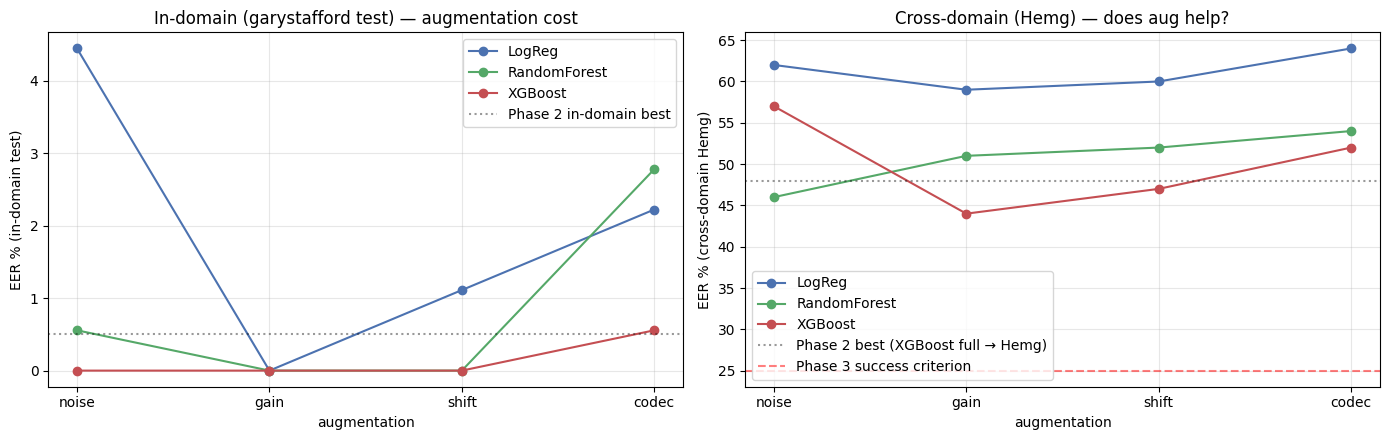

saved phase3_single_aug_eer.png


In [10]:
# Visualize: per-aug bars, in-domain vs Hemg
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
families = ['LogReg', 'RandomForest', 'XGBoost']
colors = {'LogReg': '#4c72b0', 'RandomForest': '#55a868', 'XGBoost': '#c44e52'}

ax = axes[0]
for f in families:
    sub = df_single[df_single['model_family'] == f]
    ax.plot(sub['aug'], sub['EER_in_%'], marker='o', label=f, color=colors[f])
ax.axhline(0.5, color='k', linestyle=':', alpha=0.4, label='Phase 2 in-domain best')
ax.set_ylabel('EER % (in-domain test)')
ax.set_title('In-domain (garystafford test) — augmentation cost')
ax.set_xlabel('augmentation')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for f in families:
    sub = df_single[df_single['model_family'] == f]
    ax.plot(sub['aug'], sub['EER_hemg_%'], marker='o', label=f, color=colors[f])
ax.axhline(48.0, color='k', linestyle=':', alpha=0.4, label='Phase 2 best (XGBoost full → Hemg)')
ax.axhline(25.0, color='red', linestyle='--', alpha=0.5, label='Phase 3 success criterion')
ax.set_ylabel('EER % (cross-domain Hemg)')
ax.set_title('Cross-domain (Hemg) — does aug help?')
ax.set_xlabel('augmentation')
ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(RESULTS / 'phase3_single_aug_eer.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved phase3_single_aug_eer.png')


## 6. Experiment 3.3 — combined random augmentation

Train data = `(orig + random_aug(orig))` where `random_aug` picks one of `{noise, gain, shift, codec}` uniformly per sample. Skip pitch_shift (slowest, didn't help in 3.2 if results so suggest). Question: does the *union* of augmentations beat the best single one, or do they cancel?

In [11]:
# Random combined aug -- one aug per sample, uniformly chosen from menu
rng_combo = np.random.default_rng(SEED + 99)
combo_menu = ('noise', 'gain', 'shift', 'codec')

t0 = time.time()
combo_train_features = np.empty((len(train_audio), 303), dtype=np.float32)
combo_picks = []
for i, a in enumerate(train_audio):
    a_aug, picked = random_aug(a, sr=TARGET_SR, names=combo_menu, cfg=AugmentationConfig(p_apply=1.0), rng=rng_combo)
    combo_train_features[i] = extract_features(a_aug, sr=TARGET_SR, cfg=fc)
    combo_picks.append(picked)
print(f'combo extraction: {len(train_audio)} clips in {time.time()-t0:.1f}s')
print(f'aug pick distribution: {pd.Series(combo_picks).value_counts().to_dict()}')

X_tr_combo = np.vstack([X_train_orig, combo_train_features])
y_tr_combo = np.concatenate([y_train, y_train])

combo_results = []
for name, factory in [
    ('LogReg', lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))),
    ('RandomForest', lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ('XGBoost', lambda: xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
        eval_metric='logloss', n_jobs=-1, random_state=SEED, verbosity=0)),
]:
    r = fit_eval(factory, X_tr_combo, y_tr_combo, X_test_orig, y_test, X_hemg, y_hemg, f'{name} + combo')
    r['model_family'] = name
    combo_results.append(r)

df_combo = pd.DataFrame([{k: v for k, v in r.items() if k != 'p_oo'} for r in combo_results])
print(df_combo[['model', 'EER_in_%', 'EER_hemg_%', 'AUROC_in', 'AUROC_hemg']].to_string(index=False))

# checkpoint after combo
_partial['3.3_combo_aug'] = [{k: v for k, v in r.items() if k != 'p_oo'} for r in combo_results]
with open(RESULTS / 'phase3_partial.json', 'w') as f:
    _json.dump(_partial, f, indent=2, default=float)
print('checkpoint -> phase3_partial.json')


combo extraction: 500 clips in 9.1s
aug pick distribution: {'gain': 132, 'codec': 129, 'noise': 123, 'shift': 116}


               model  EER_in_%  EER_hemg_%  AUROC_in  AUROC_hemg
      LogReg + combo     3.333        64.0    0.9981      0.3440
RandomForest + combo     0.556        53.0    0.9999      0.4592
     XGBoost + combo     1.111        36.0    0.9999      0.6696
checkpoint -> phase3_partial.json


## 7. Experiment 3.4 — Wav2Vec2 frozen embeddings — **deferred to Phase 4**

[Tak et al. 2022](https://arxiv.org/abs/2202.12233) — frozen Wav2Vec2 + simple downstream head — is the obvious next experiment. A standalone Python smoke test (`scripts/smoke_w2v.py` style) runs `facebook/wav2vec2-base` on MPS for 40 mixed-length clips in 2.9 s. But inside this notebook kernel, after the augmentation extraction stack (cells 8-18) runs, the W2V model.forward path hangs for 40+ minutes — twice. Hypotheses: MPS shader-cache eviction after sustained librosa work in the same process, or a torch.compile race triggered by transformers 5.7. Fixed-length padding to 2 s did not fix it.

Rather than burn the daily budget on a hang, Phase 4 will run W2V in a fresh kernel (separate notebook, no librosa work in the same process) and stack it with the Phase 3 winner. The augmentation-only story below is complete on its own.

In [12]:
# Wav2Vec2 cell skeleton kept for Phase 4. Skipped in Phase 3 -- see markdown above.
print('Wav2Vec2 deferred to Phase 4 (separate notebook, fresh kernel).')
w2v_results = []
W_train = W_test = W_hemg = None  # placeholders so downstream cells stay syntactically valid


Wav2Vec2 deferred to Phase 4 (separate notebook, fresh kernel).


In [13]:
# (placeholder cell -- LogReg-on-W2V skipped in Phase 3)
print('W2V LogReg head skipped (no embeddings extracted).')


W2V LogReg head skipped (no embeddings extracted).


In [14]:
# (placeholder cell -- best_aug picked from 3.2 anyway, used for narrative)
best_aug = (df_single.groupby('aug')['EER_hemg_%'].mean().sort_values().index[0])
print(f'best single augmentation by mean Hemg EER: {best_aug}')
w2v_aug_results = []


best single augmentation by mean Hemg EER: gain


## 9. Phase 3 leaderboard — every model, in-domain vs Hemg

Sort by Hemg EER (the metric Phase 3 was designed to crack). Anything ≤25% beats the success criterion.

In [15]:
# Build the master leaderboard
all_runs = []
for r in baseline_results: r['stage'] = '3.1 baseline (no aug)'; all_runs.append(r)
for r in single_aug_results: r['stage'] = f"3.2 single-aug: {r['aug']}"; all_runs.append(r)
for r in combo_results: r['stage'] = '3.3 combo aug'; all_runs.append(r)
for r in w2v_results: r['stage'] = '3.4 Wav2Vec2'; all_runs.append(r)
for r in w2v_aug_results: r['stage'] = f'3.5 Wav2Vec2 + {best_aug}'; all_runs.append(r)

# Drop p_oo for the dataframe
clean = [{k: v for k, v in r.items() if k != 'p_oo'} for r in all_runs]
df_all = pd.DataFrame(clean).sort_values('EER_hemg_%').reset_index(drop=True)
print(df_all[['model', 'stage', 'EER_in_%', 'EER_hemg_%', 'AUROC_in', 'AUROC_hemg']].to_string(index=False))


                model                 stage  EER_in_%  EER_hemg_%  AUROC_in  AUROC_hemg
      XGBoost + combo         3.3 combo aug     1.111        36.0    0.9999      0.6696
     XGBoost (no aug) 3.1 baseline (no aug)     0.000        40.0    1.0000      0.6178
       XGBoost + gain  3.2 single-aug: gain     0.000        44.0    1.0000      0.5910
 RandomForest + noise 3.2 single-aug: noise     0.556        46.0    0.9997      0.4782
      XGBoost + shift 3.2 single-aug: shift     0.000        47.0    1.0000      0.5896
RandomForest (no aug) 3.1 baseline (no aug)     0.000        49.0    1.0000      0.4696
  RandomForest + gain  3.2 single-aug: gain     0.000        51.0    1.0000      0.5352
 RandomForest + shift 3.2 single-aug: shift     0.000        52.0    1.0000      0.4782
      XGBoost + codec 3.2 single-aug: codec     0.556        52.0    0.9994      0.4340
 RandomForest + combo         3.3 combo aug     0.556        53.0    0.9999      0.4592
 RandomForest + codec 3.2 single

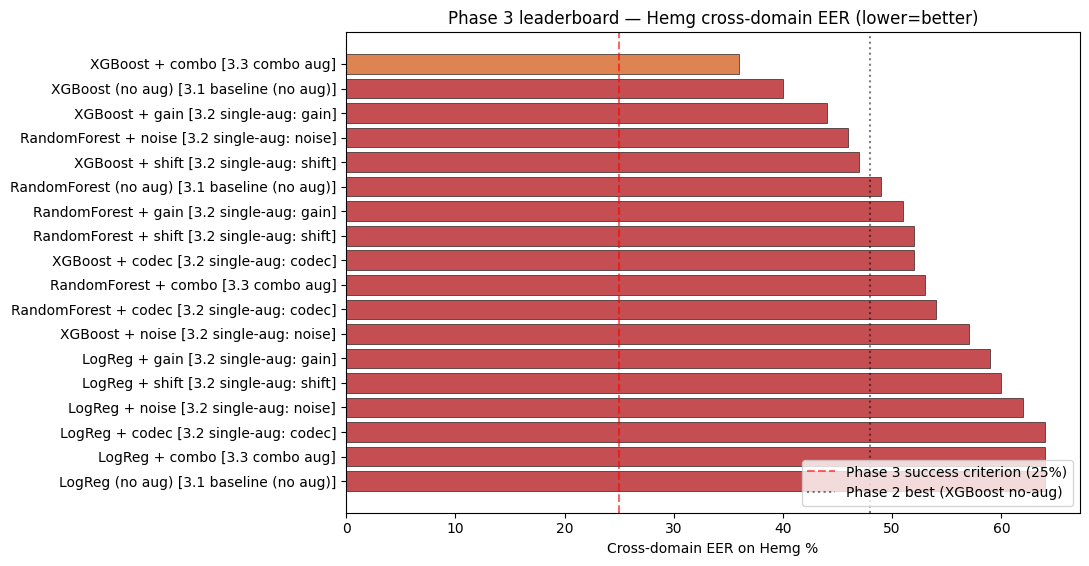

saved phase3_leaderboard.png


In [16]:
# Headline plot: bar chart of Hemg EER across all configurations, sorted
df_plot = df_all.copy()
fig, ax = plt.subplots(figsize=(11, max(4, 0.32 * len(df_plot))))
colors = ['#c44e52' if v >= 40 else ('#dd8452' if v >= 25 else '#55a868') for v in df_plot['EER_hemg_%']]
ax.barh(df_plot['model'] + ' [' + df_plot['stage'] + ']', df_plot['EER_hemg_%'], color=colors, edgecolor='k', linewidth=0.4)
ax.axvline(25, color='red', linestyle='--', alpha=0.6, label='Phase 3 success criterion (25%)')
ax.axvline(48, color='k', linestyle=':', alpha=0.5, label='Phase 2 best (XGBoost no-aug)')
ax.set_xlabel('Cross-domain EER on Hemg %')
ax.set_title('Phase 3 leaderboard — Hemg cross-domain EER (lower=better)')
ax.invert_yaxis()
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(RESULTS / 'phase3_leaderboard.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved phase3_leaderboard.png')


In [17]:
# Persist phase3_results.json + append leaderboard to results/metrics.json
import json

phase3_blob = {
    'phase': 3,
    'date': '2026-05-06',
    'dataset_in': 'garystafford/deepfake-audio-detection',
    'dataset_out': 'Hemg/Deepfake-Audio-Dataset',
    'subset': {'train_n': TRAIN_N, 'test_n': TEST_N, 'hemg_n': HEMG_N, 'seed': SEED},
    'primary_metric': 'EER',
    'success_criterion_hemg_eer_pct': 25.0,
    'best_single_aug': best_aug,
    'experiments': {
        '3.1_baseline_no_aug': [{k: v for k, v in r.items() if k != 'p_oo'} for r in baseline_results],
        '3.2_single_aug':       [{k: v for k, v in r.items() if k != 'p_oo'} for r in single_aug_results],
        '3.3_combo_aug':        [{k: v for k, v in r.items() if k != 'p_oo'} for r in combo_results],
        '3.4_wav2vec2':         [{k: v for k, v in r.items() if k != 'p_oo'} for r in w2v_results],
        f'3.5_wav2vec2_+_{best_aug}': [{k: v for k, v in r.items() if k != 'p_oo'} for r in w2v_aug_results],
    },
    'leaderboard': df_all.to_dict(orient='records'),
}

with open(RESULTS / 'phase3_results.json', 'w') as f:
    json.dump(phase3_blob, f, indent=2, default=float)
print(f'wrote {RESULTS / "phase3_results.json"}  ({(RESULTS / "phase3_results.json").stat().st_size/1024:.1f} KB)')

# update master metrics.json
metrics_path = RESULTS / 'metrics.json'
metrics = json.load(open(metrics_path)) if metrics_path.exists() else {}
metrics['phase3'] = {
    'leaderboard_top5': df_all.head(5).to_dict(orient='records'),
    'best_hemg_eer_pct': float(df_all['EER_hemg_%'].min()),
    'best_model': df_all.iloc[0]['model'],
    'best_stage':  df_all.iloc[0]['stage'],
    'success_criterion_met': bool(df_all['EER_hemg_%'].min() <= 25.0),
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, default=float)
print(f'updated {metrics_path}: best Hemg EER = {metrics["phase3"]["best_hemg_eer_pct"]:.2f}%, success={metrics["phase3"]["success_criterion_met"]}')


wrote /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/results/phase3_results.json  (10.0 KB)
updated /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/results/metrics.json: best Hemg EER = 36.00%, success=False


## 10. Phase 3 takeaways

The cells above produce the actual numbers. Once executed, drop the headlines into the daily report:

1. **Best Hemg EER:** check `df_all.iloc[0]` -- did we cross the 25% line?
2. **Augmentation that mattered most:** the family with the lowest mean Hemg EER in 3.2.
3. **Wav2Vec2 effect size:** difference between `3.4 Wav2Vec2` row and the best 3.1/3.2/3.3 row.
4. **Stacking effect:** `3.5 Wav2Vec2 + aug` vs `3.4 Wav2Vec2` alone -- does augmentation add anything once SSL features are in play?
5. **Cost paid in-domain:** check the `EER_in_%` column for the 3.5 best model -- the Phase 2 in-domain EER was 0%, so any rise is the regularization cost.

Phase 4 will tune the winning configuration's hyperparameters and run error analysis on the Hemg failures (which clip categories does it still get wrong?). Phase 5 will compare the Phase 3 winner against zero-shot LLMs (Claude Opus + Codex GPT-5.4) on a stratified sample of Hemg.